In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)

In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
df = pd.read_csv(r'E:/CUSTOMER_CHURN/01_data/Telco_Customer_Churn.csv')
print("Data Loaded:", df.shape)

Data Loaded: (7043, 22)


In [24]:
df.drop('customerID', axis=1, inplace=True)

In [25]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [26]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
print("Preprocessing Done")
print("Churn Distribution:\n", df['Churn'].value_counts())

Preprocessing Done
Churn Distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [28]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (5634, 20), Test size: (1409, 20)


In [30]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(classification_report(y_test, lr_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, lr_prob):.4f}")


LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

AUC-ROC Score: 0.8381


In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(classification_report(y_test, rf_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, rf_prob):.4f}")


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

AUC-ROC Score: 0.8157


In [32]:
lr_cv = cross_val_score(lr, X, y, cv=5, scoring='roc_auc')
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print("\n" + "="*50)
print("CROSS VALIDATION (5-Fold AUC-ROC)")
print("="*50)
print(f"Logistic Regression: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"Random Forest:       {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")


CROSS VALIDATION (5-Fold AUC-ROC)
Logistic Regression: 0.8426 ± 0.0105
Random Forest:       0.8222 ± 0.0122



Plot saved!


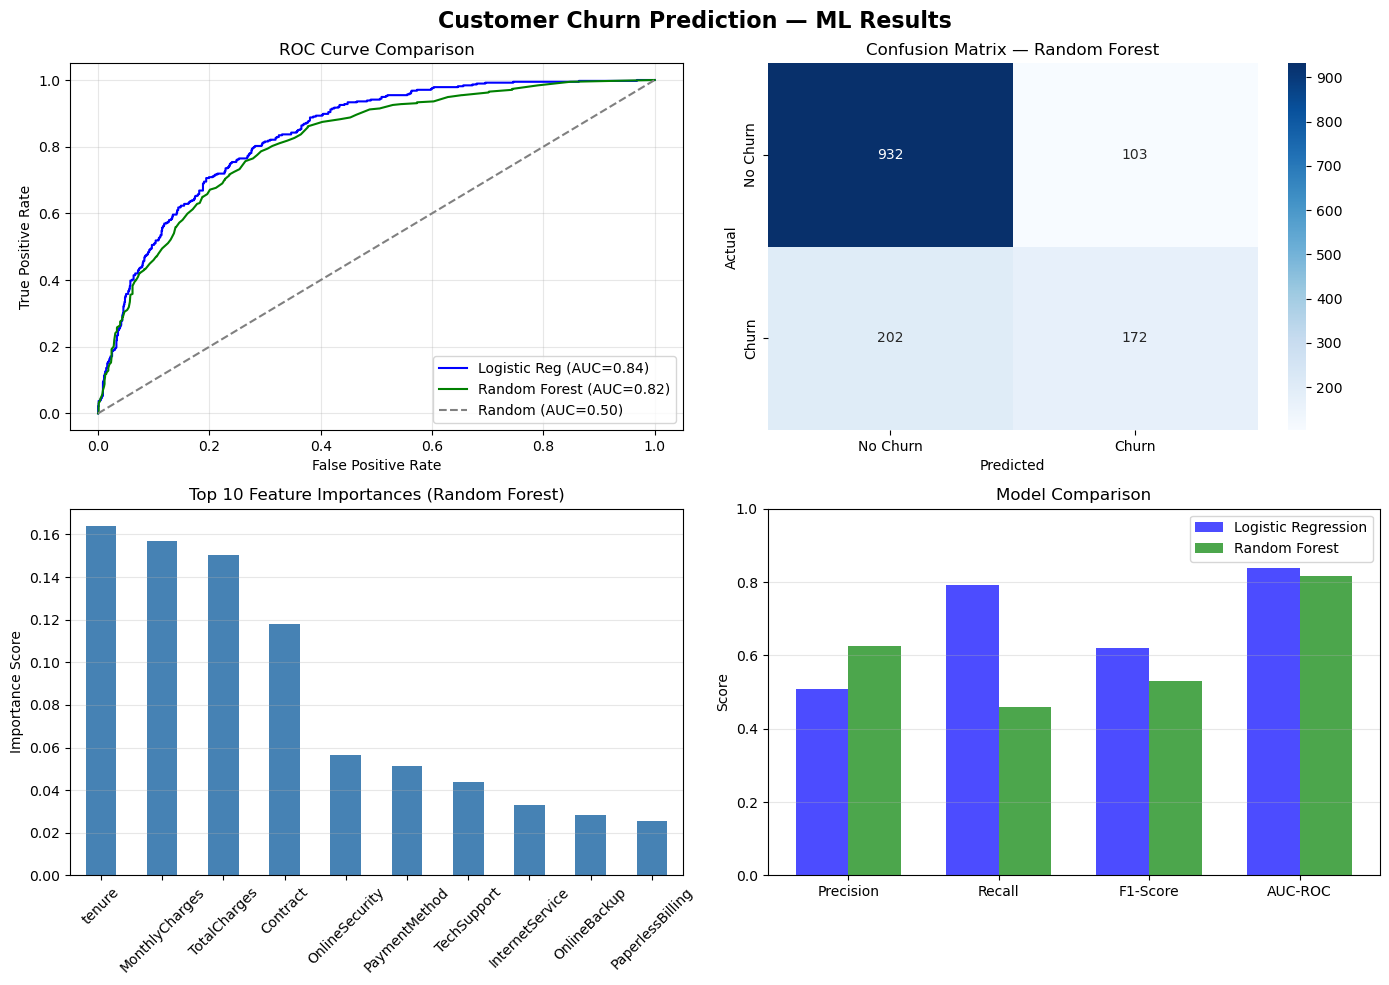

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Prediction — ML Results', fontsize=16, fontweight='bold')
# Plot 1: ROC Curves
ax1 = axes[0, 0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
ax1.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test, lr_prob):.2f})', color='blue')
ax1.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_prob):.2f})', color='green')
ax1.plot([0,1],[0,1],'--', color='gray', label='Random (AUC=0.50)')
ax1.set_title('ROC Curve Comparison')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix - Random Forest
ax2 = axes[0, 1]
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax2.set_title('Confusion Matrix — Random Forest')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

# Plot 3: Feature Importance
ax3 = axes[1, 0]
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
feat_imp.plot(kind='bar', ax=ax3, color='steelblue')
ax3.set_title('Top 10 Feature Importances (Random Forest)')
ax3.set_ylabel('Importance Score')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Model Comparison Bar Chart
ax4 = axes[1, 1]
metrics = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
from sklearn.metrics import precision_score, recall_score
lr_scores = [
    precision_score(y_test, lr_pred),
    recall_score(y_test, lr_pred),
    f1_score(y_test, lr_pred),
    roc_auc_score(y_test, lr_prob)
]
rf_scores = [
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred),
    roc_auc_score(y_test, rf_prob)
]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='blue', alpha=0.7)
ax4.bar(x + width/2, rf_scores, width, label='Random Forest', color='green', alpha=0.7)
ax4.set_title('Model Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_ylabel('Score')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(r'E:/CUSTOMER_CHURN/03_python/churn_ml_results.png', dpi=150, bbox_inches='tight')
print("\nPlot saved!")

In [34]:
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
winner = "Random Forest" if roc_auc_score(y_test, rf_prob) > roc_auc_score(y_test, lr_prob) else "Logistic Regression"
print(f"Best Model: {winner}")
print(f"\nTop 5 Features Driving Churn:")
for feat, imp in feat_imp.head(5).items():
    print(f"  → {feat}: {imp:.4f}")


FINAL SUMMARY
Best Model: Logistic Regression

Top 5 Features Driving Churn:
  → tenure: 0.1639
  → MonthlyCharges: 0.1568
  → TotalCharges: 0.1502
  → Contract: 0.1178
  → OnlineSecurity: 0.0565
